# Growth and reach of UK Biobank research

This notebook replaces the previous 01_* analyses with one reproducible account of how the UK Biobank publication corpus and its linked academic and non-academic reach have accumulated over time.

Primary figures use complete publication years (2013–2025). Records dated 2026 are retained in the data audit but excluded from trend estimates because 2026 is incomplete and includes future-dated records. Figure 1 counts unique publications carrying each indicator by publication year. Separate endpoint summaries deduplicate linked records by Dimensions identifier and assign each record to the year of its earliest linked UK Biobank publication.

All paths printed by this notebook are repository-relative.

In [1]:
from __future__ import annotations

import sys
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "utils").is_dir()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from utils import shared_paths as P
from utils import data_analysis_01_growth as G
from utils.shared_style import load_style, savefig, semantic_colors

P.bootstrap()
P.ensure_dirs()
STYLE = load_style("01_growth")
METRIC_COLORS = semantic_colors()
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)
GRID_KWS = {
    "color": "#D9D9D9",
    "linestyle": STYLE.get("grid_linestyle", "--"),
    "linewidth": 0.75,
    "alpha": 0.72,
}

DATA_CUTOFF = pd.Timestamp("2026-08-26")
LAST_COMPLETE_YEAR = DATA_CUTOFF.year - 1
TABLE_DIR = P.TABLE_GROWTH

ARTIFACTS = P.ArtifactRegistry(TABLE_DIR)
save_table = ARTIFACTS.save_table
record_figure = ARTIFACTS.record_figures

print("input:", P.raw_path(P.SHOWCASE_PLUS))
print("figures:", P.raw_path(P.FIG_GROWTH))
print("tables:", P.raw_path(P.TABLE_GROWTH))
print("data cutoff:", DATA_CUTOFF.date())
print("last complete publication year:", LAST_COMPLETE_YEAR)

input: data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
figures: output/figures/data_analysis/01_growth
tables: output/tables/data_analysis/01_growth
data cutoff: 2026-08-26
last complete publication year: 2025


## Metric definitions

- **Papers:** unique Dimensions publication IDs, counted by publication year.
- **Linked-publication indicators:** a paper has at least one linked clinical-trial, patent, policy-document, grant, or dataset ID. A paper contributes once to each applicable indicator in its publication year.
- **Unique linked records:** deduplicated endpoint IDs, assigned to the publication year of their earliest linked UK Biobank paper for first-link summaries. Event-year tables instead use the recorded trial start, patent publication, policy, grant start, or dataset year.
- **Cross-sector collaboration:** a paper listing at least one Education organization and at least one Company, Government, Healthcare, or Nonprofit organization.
- **Altmetric attention:** papers with a positive aggregate Altmetric score. Scores are current-snapshot attributes, not dated mention events.
- **Citations:** current Dimensions citation counts grouped by paper publication year.
- **News mentions:** unavailable in this parquet. The source includes aggregate Altmetric score and ID, but no news-specific count; no news values are inferred.
- **Headline growth interval:** 2018–2025. Earlier annual counts are retained throughout but are too sparse for a stable headline growth rate.
- **2026:** audited but excluded from primary trends, growth rates, and endpoint-cohort totals.

In [2]:
ENDPOINT_SPECS = G.ENDPOINT_SPECS
papers = G.load_growth_papers()

print(f"loaded {len(papers):,} rows and {len(papers.columns):,} selected columns")
print(f"unique publication IDs: {papers['id'].nunique():,}")
print(
    "publication years:",
    int(papers["year"].min()),
    "to",
    int(papers["year"].max()),
)

loaded 26,109 rows and 29 selected columns
unique publication IDs: 26,109
publication years: 2013 to 2026


In [3]:
papers = G.add_publication_indicators(papers, DATA_CUTOFF)

papers[
    [
        "cross_sector_collaboration",
        "international_collaboration",
        "has_altmetric_attention",
        "is_open_access",
    ]
].mean().mul(100).rename("percent_of_all_records").round(1).to_frame()

,percent_of_all_records
cross_sector_collaboration,57.6
international_collaboration,41.7
has_altmetric_attention,68.9
is_open_access,81.6


## Endpoint reconstruction and quality controls

The wide parquet stores linked IDs and endpoint dates as parallel JSON arrays. The following cell reconstructs one link per row, checks array alignment, deduplicates endpoint IDs, and resolves repeated event-year values by modal year (earliest year breaks ties). Endpoint IDs without a corresponding date are retained in link-based counts and marked as missing for event-year analyses; the original link rows are retained for audit tables.

In [4]:
endpoint_links, endpoint_unique, endpoint_audits = G.reconstruct_all_endpoints(papers)
endpoint_audit = pd.DataFrame(endpoint_audits)
display(endpoint_audit)

,endpoint,label,parsed_link_rows,recorded_n_records_sum,record_count_difference,unique_endpoint_ids,alignment_mismatch_paper_rows,links_missing_event_year,unique_ids_with_event_year,unique_ids_with_conflicting_event_year
0,clinical_trials,Clinical trials,254,254,0,195,0,2,194,0
1,patents,Patents,1098,1098,0,767,0,0,767,0
2,policy_documents,Policy documents,677,677,0,449,0,0,449,0
3,grants,Grants,82983,82975,8,15619,8,449,15590,72
4,datasets,Datasets,5536,5536,0,5536,0,8,5528,0


In [5]:
quality_audit = G.build_quality_audit(papers, endpoint_audits, DATA_CUTOFF)
save_table(quality_audit, "data_quality_audit.csv")

complete = G.complete_year_corpus(papers, LAST_COMPLETE_YEAR)

print(f"complete-year analytical corpus: {len(complete):,} papers")
print(
    f"excluded provisional 2026 records: "
    f"{papers['year'].eq(DATA_CUTOFF.year).sum():,}"
)
print(f"future-dated records in source: {papers['future_dated'].sum():,}")
display(quality_audit)

saved output/tables/data_analysis/01_growth/data_quality_audit.csv
complete-year analytical corpus: 23,442 papers
excluded provisional 2026 records: 2,667
future-dated records in source: 4


,check,value,interpretation
0,input_rows,26109,All parquet records
1,unique_publication_ids,26109,Expected to equal input rows
2,duplicate_publication_ids,0,Expected zero
3,missing_publication_year,0,Expected zero
4,missing_publication_date,0,Expected zero
5,date_year_mismatches,0,Date year differs from year field
6,records_after_data_cutoff,4,Future-dated; excluded with 2026
7,records_in_incomplete_2026,2667,Provisional year; excluded from primary analyses
8,clinical_trials_array_alignment_mismatches,0,ID and event-date arrays of different lengths
9,patents_array_alignment_mismatches,0,ID and event-date arrays of different lengths


## Annual and cumulative growth metrics

All cumulative series below end in 2025. Endpoint series count a unique linked object once, in the first publication year through which it enters the UK Biobank corpus.

In [6]:
annual, sector_by_year, event_year_metrics, event_year_baseline_table = (
    G.build_annual_outputs(complete, endpoint_unique, LAST_COMPLETE_YEAR)
)
FIRST_YEAR = int(annual.index.min())
YEARS = annual.index
annual_out = annual.reset_index()
save_table(annual_out, "annual_growth_metrics.csv")

save_table(sector_by_year, "cross_sector_collaboration_by_year.csv")
save_table(event_year_metrics, "endpoint_event_year_metrics.csv")
save_table(event_year_baseline_table, "endpoint_event_year_audit.csv")

display(
    annual_out[
        [
            "year", "annual_papers", "cumulative_papers",
            "yoy_publication_growth_pct", "median_authors",
            "share_cross_sector_collaboration_pct",
            "share_international_collaboration_pct",
            "share_has_altmetric_attention_pct",
        ]
    ].round(1)
)

saved output/tables/data_analysis/01_growth/annual_growth_metrics.csv
saved output/tables/data_analysis/01_growth/cross_sector_collaboration_by_year.csv
saved output/tables/data_analysis/01_growth/endpoint_event_year_metrics.csv
saved output/tables/data_analysis/01_growth/endpoint_event_year_audit.csv


,year,annual_papers,cumulative_papers,yoy_publication_growth_pct,median_authors,share_cross_sector_collaboration_pct,share_international_collaboration_pct,share_has_altmetric_attention_pct
0,2013,5,5,NaN,7.0,20.0,40.0,100.0
1,2014,27,32,440.0,7.0,37.0,44.4,74.1
2,2015,63,95,133.3,7.0,54.0,42.9,87.3
3,2016,160,255,154.0,10.0,64.4,53.8,89.4
4,2017,310,565,93.8,8.0,53.9,49.0,84.5
5,2018,616,1181,98.7,9.0,58.1,53.7,88.6
6,2019,1023,2204,66.1,8.0,54.0,50.7,85.1
7,2020,1631,3835,59.4,7.0,56.2,49.2,86.3
8,2021,2273,6108,39.4,7.0,55.7,48.8,81.4
9,2022,2792,8900,22.8,8.0,56.6,45.3,82.4


## Headline statistics, milestones, and endpoint coverage

In [7]:
latest = LAST_COMPLETE_YEAR
baseline = 2018
growth_stats = G.growth_statistics(annual, baseline, latest)
cagr = growth_stats["cagr"]
doubling_years = growth_stats["doubling_years"]

milestones = G.publication_milestones(complete)
save_table(milestones, "publication_milestones.csv")

endpoint_summary = G.summarize_endpoints(
    complete, endpoint_links, endpoint_unique, LAST_COMPLETE_YEAR
)
save_table(endpoint_summary, "endpoint_summary.csv")

headline = G.headline_summary(
    papers, complete, annual, growth_stats, baseline, latest, DATA_CUTOFF
)
save_table(headline, "headline_summary_statistics.csv")

metric_definitions = G.metric_definitions_table()
save_table(metric_definitions, "metric_definitions.csv")

print(f"{len(complete):,} papers were published in complete years {FIRST_YEAR}–{latest}.")
print(
    f"Annual output rose from {annual.loc[baseline, 'annual_papers']:,} papers in "
    f"{baseline} to {annual.loc[latest, 'annual_papers']:,} in {latest} "
    f"(CAGR {cagr:.1%}; estimated doubling time {doubling_years:.2f} years)."
)
print(
    f"{complete['cross_sector_collaboration'].mean():.1%} of papers were cross-sector "
    f"collaborations and {complete['international_collaboration'].mean():.1%} were international."
)
print(
    f"The top 1% of papers account for {G.top_share(complete['altmetric']):.1%} of "
    f"aggregate Altmetric score and {G.top_share(complete['times_cited']):.1%} of citations."
)
print("News-specific mentions are unavailable and are not estimated.")
display(headline)
display(endpoint_summary.round(2))
display(milestones)

saved output/tables/data_analysis/01_growth/publication_milestones.csv
saved output/tables/data_analysis/01_growth/endpoint_summary.csv
saved output/tables/data_analysis/01_growth/headline_summary_statistics.csv
saved output/tables/data_analysis/01_growth/metric_definitions.csv
23,442 papers were published in complete years 2013–2025.
Annual output rose from 616 papers in 2018 to 5,892 in 2025 (CAGR 38.1%; estimated doubling time 2.21 years).
57.3% of papers were cross-sector collaborations and 42.3% were international.
The top 1% of papers account for 45.2% of aggregate Altmetric score and 32.9% of citations.
News-specific mentions are unavailable and are not estimated.


,metric,value,definition
0,All source records,"26,109",Includes provisional 2026 records
1,Papers in complete years,"23,442",Unique papers published 2013–2025
2,Papers published in 2025,"5,892",Latest complete publication year
3,Year-on-year growth in 2025,19.1%,Relative to 2024
4,"Publication CAGR, 2018–2025",38.1%,Compound annual growth in annual paper output
5,"Log-linear annual growth, 2018–2025",36.9%,OLS on log annual counts; R²=0.974
6,Estimated publication doubling time,2.21 years,From 2018–2025 log-linear trend
7,Cross-sector collaboration papers,"13,425","Education plus Company, Government, Healthcare, or Nonprofit"
8,International collaboration papers,"9,926",At least two research-organization countries
9,Papers with Altmetric attention,"16,532",Positive aggregate Altmetric score


,endpoint,label,linked_papers_2013_2025,link_rows_from_complete_year_papers,unique_records_first_linked_by_2025,event_year_coverage_pct,records_with_conflicting_event_year,median_linked_papers_per_record,earliest_first_link_year,latest_first_link_year
0,clinical_trials,Clinical trials,194,252,193,99.48,0,1.0,2013,2025
1,patents,Patents,513,1098,767,100.00,0,1.0,2014,2025
2,policy_documents,Policy documents,369,677,449,100.00,0,1.0,2013,2025
3,grants,Grants,13252,78073,14847,99.81,72,2.0,2013,2025
4,datasets,Datasets,1532,5162,5162,99.86,0,1.0,2013,2025


,cumulative_papers,date_reached,year
0,100,2016-01-04,2016
1,1000,2018-09-21,2018
2,5000,2021-07-09,2021
3,10000,2023-05-02,2023
4,20000,2025-06-11,2025


## Main figure

Panel A combines the cumulative publication trajectory with six publication-indicator insets on the same cohort timeline. The same six indicators are used throughout: patents, clinical trials, policy documents, datasets, cross-sector collaboration and Altmetric attention. The analytical rail shows annual output (B), full-period indicator prevalence per 1,000 publications (C), and directional co-occurrence among the six indicators across the cumulative corpus (D).

saved output/tables/data_analysis/01_growth/analysis_validation_checks.csv
validation: 35/35 checks passed


,scope,checks,passed
0,source,4,4
1,corpus,3,3
2,annual,4,4
3,indicator,12,12
4,overlap,2,2
5,endpoint,10,10


saved output/figures/data_analysis/01_growth/01_01_figure_01_growth_and_reach.pdf


saved output/figures/data_analysis/01_growth/01_01_figure_01_growth_and_reach.svg


saved output/figures/data_analysis/01_growth/01_01_figure_01_growth_and_reach.png


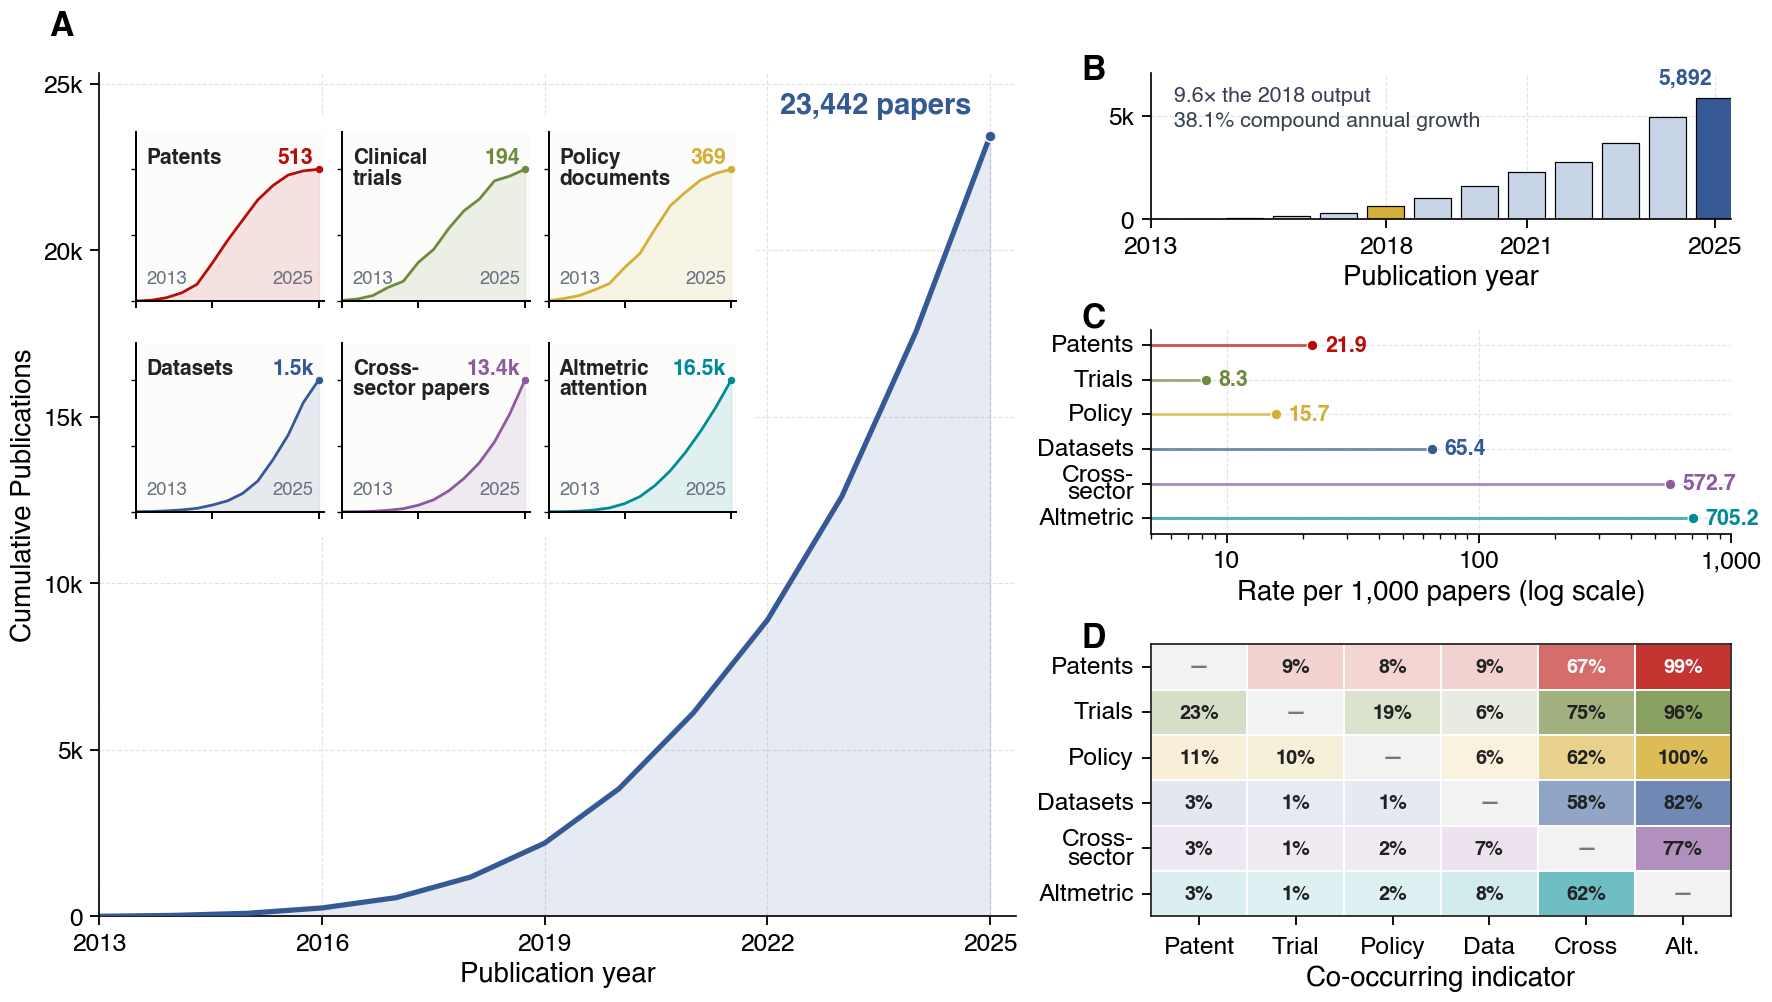

saved output/tables/data_analysis/01_growth/figure_01_indicator_rates.csv
saved output/tables/data_analysis/01_growth/figure_01_indicator_overlap.csv
saved output/tables/data_analysis/01_growth/figure_01_growth_and_reach_data.csv


In [8]:
MAIN_INDICATORS = G.main_indicator_specs(METRIC_COLORS)
indicator_rate_table, conditional_overlap, overlap_export = (
    G.main_indicator_tables(complete, annual, MAIN_INDICATORS, latest)
)

validation_checks = G.validate_growth_analysis(
    papers, complete, annual, endpoint_unique, MAIN_INDICATORS,
    indicator_rate_table, conditional_overlap, DATA_CUTOFF, LAST_COMPLETE_YEAR,
)
save_table(validation_checks, "analysis_validation_checks.csv")
validation_summary = (
    validation_checks.groupby("scope", sort=False)
    .agg(checks=("passed", "size"), passed=("passed", "sum"))
    .reset_index()
)
print(f"validation: {validation_checks['passed'].sum()}/{len(validation_checks)} checks passed")
display(validation_summary)

PLOT = G.GrowthPlotter(
    STYLE, YEARS, FIRST_YEAR, LAST_COMPLETE_YEAR, baseline, GRID_KWS
)

fig = G.plot_growth_and_reach(
    annual,
    MAIN_INDICATORS,
    indicator_rate_table,
    conditional_overlap,
    STYLE,
    METRIC_COLORS,
    PLOT,
    baseline,
    latest,
    cagr,
)
record_figure(savefig(fig, "01_01_figure_01_growth_and_reach"))
plt.show()
plt.close(fig)

_ = save_table(
    indicator_rate_table.drop(columns="color").round(
        {"publications_per_1000": 1}
    ),
    "figure_01_indicator_rates.csv",
)
_ = save_table(
    overlap_export,
    "figure_01_indicator_overlap.csv",
)

figure_data_columns = [
    "year", "annual_papers", "cumulative_papers",
    "cumulative_papers_linked_patents", "cumulative_papers_linked_clinical_trials",
    "cumulative_papers_linked_policy_documents", "cumulative_papers_linked_datasets",
    "cumulative_cross_sector_papers", "cumulative_altmetric_papers",
    "cumulative_unique_grants", "cumulative_citations_snapshot",
]
_ = save_table(annual_out[figure_data_columns], "figure_01_growth_and_reach_data.csv")

## Additional temporal summaries

The first table partitions the observation window into three descriptive periods to show how annual output and the composition of the complete-year corpus changed over time. These periods are summaries, not estimated structural breaks, and the earliest interval's relative growth measures are sensitive to its very small starting base. The second table reports when each of the six Figure 1 indicators reached 25%, 50%, and 75% of its observed cumulative total. Indicator milestones describe the available linkage snapshot and should not be interpreted as causal effects; recent linked-endpoint cohorts may be affected by indexing and linkage latency.

In [9]:
phase_windows = G.growth_phase_windows(FIRST_YEAR, LAST_COMPLETE_YEAR)
growth_period_summary = G.growth_period_summary(annual, complete, phase_windows)
save_table(growth_period_summary, "growth_period_summary.csv")

indicator_accumulation_milestones = G.indicator_accumulation_milestones(
    annual, MAIN_INDICATORS, LAST_COMPLETE_YEAR
)
save_table(
    indicator_accumulation_milestones,
    "indicator_accumulation_milestones.csv",
)

corpus_half_year = int(
    annual.index[annual["cumulative_papers"].ge(len(complete) * 0.5)][0]
)
print(f"Half of the complete-year publication corpus had accumulated by {corpus_half_year}.")
print("Indicator milestone years refer to observed publication indicators, not event dates.")
display(growth_period_summary.round(1))
display(indicator_accumulation_milestones)

saved output/tables/data_analysis/01_growth/growth_period_summary.csv
saved output/tables/data_analysis/01_growth/indicator_accumulation_milestones.csv
Half of the complete-year publication corpus had accumulated by 2023.
Indicator milestone years refer to observed publication indicators, not event dates.


,period,papers_published,share_of_complete_year_corpus_pct,annual_output_first_year,annual_output_last_year,annual_output_cagr_pct,median_yoy_growth_pct
0,2013-2017,565,2.4,5,310,180.6,143.7
1,2018-2021,5543,23.6,616,2273,54.5,59.4
2,2022-2025,17334,73.9,2792,5892,28.3,32.6


,indicator,observed_cumulative_papers,year_at_25pct,year_at_50pct,year_at_75pct,years_from_25pct_to_75pct
0,Patents,513,2018,2020,2021,3
1,Clinical trials,194,2018,2020,2022,4
2,Policy documents,369,2018,2020,2022,4
3,Datasets,1532,2022,2023,2024,2
4,Cross-sector collaboration,13425,2021,2023,2025,4
5,Altmetric attention,16532,2021,2023,2024,3


## Publication and collaboration composition

These descriptive summaries add context to publication growth by showing how team structure, collaboration, and publication type vary across the same periods. Current Altmetric-attention and open-access snapshots are not compared between periods here because recent cohorts may be affected by attention accrual, indexing, and access-status latency. The cross-sector table separates Company, Government, Healthcare, and Nonprofit participation; these categories are not mutually exclusive, so their counts should not be summed.

In [10]:
period_composition_summary = G.period_composition_summary(complete, phase_windows)
save_table(period_composition_summary, "period_composition_summary.csv")

cross_sector_composition, multiple_sector_count = (
    G.cross_sector_composition_summary(complete)
)
save_table(cross_sector_composition, "cross_sector_composition_summary.csv")

cross_sector_total = int(cross_sector_composition.iloc[0]["papers"])
largest_sector = cross_sector_composition.iloc[1:].sort_values("papers", ascending=False).iloc[0]
print(
    f"{largest_sector['non_academic_sector']} was the most frequent recorded non-academic "
    f"sector, appearing in {int(largest_sector['papers']):,} cross-sector papers."
)
print(
    f"{multiple_sector_count:,} cross-sector papers "
    f"({multiple_sector_count / cross_sector_total:.1%}) included at least two listed "
    "non-academic sector types."
)
display(period_composition_summary.round(1))
display(cross_sector_composition.round(1))

saved output/tables/data_analysis/01_growth/period_composition_summary.csv
saved output/tables/data_analysis/01_growth/cross_sector_composition_summary.csv
Healthcare was the most frequent recorded non-academic sector, appearing in 11,842 cross-sector papers.
4,159 cross-sector papers (31.0%) included at least two listed non-academic sector types.


,period,papers,median_authors,authors_q25,authors_q75,cross_sector_pct,international_pct,preprint_pct
0,2013-2017,565,8.0,5.0,15.0,55.8,49.4,20.2
1,2018-2021,5543,8.0,5.0,13.0,55.8,49.8,27.9
2,2022-2025,17334,8.0,5.0,11.0,57.8,39.7,19.2


,non_academic_sector,papers,share_of_all_papers_pct,share_of_cross_sector_papers_pct,earliest_publication_year,latest_publication_year
0,Any listed sector,13425,57.3,100.0,2013,2025
1,Company,1546,6.6,11.5,2015,2025
2,Government,2596,11.1,19.3,2013,2025
3,Healthcare,11842,50.5,88.2,2013,2025
4,Nonprofit,2922,12.5,21.8,2015,2025


## Supplementary figure 1: annual growth, collaboration, and reach

Annual publication counts and year-on-year growth are shown alongside authors per paper, collaboration composition, publication characteristics, and linked-record prevalence. The author band is the interquartile range. Panel F uses a logarithmic scale because linked-record prevalence differs by orders of magnitude; zero-valued years are omitted only from that log-scaled panel.

saved output/figures/data_analysis/01_growth/01_02_supplementary_figure_01_annual_growth.pdf


saved output/figures/data_analysis/01_growth/01_02_supplementary_figure_01_annual_growth.svg


saved output/figures/data_analysis/01_growth/01_02_supplementary_figure_01_annual_growth.png


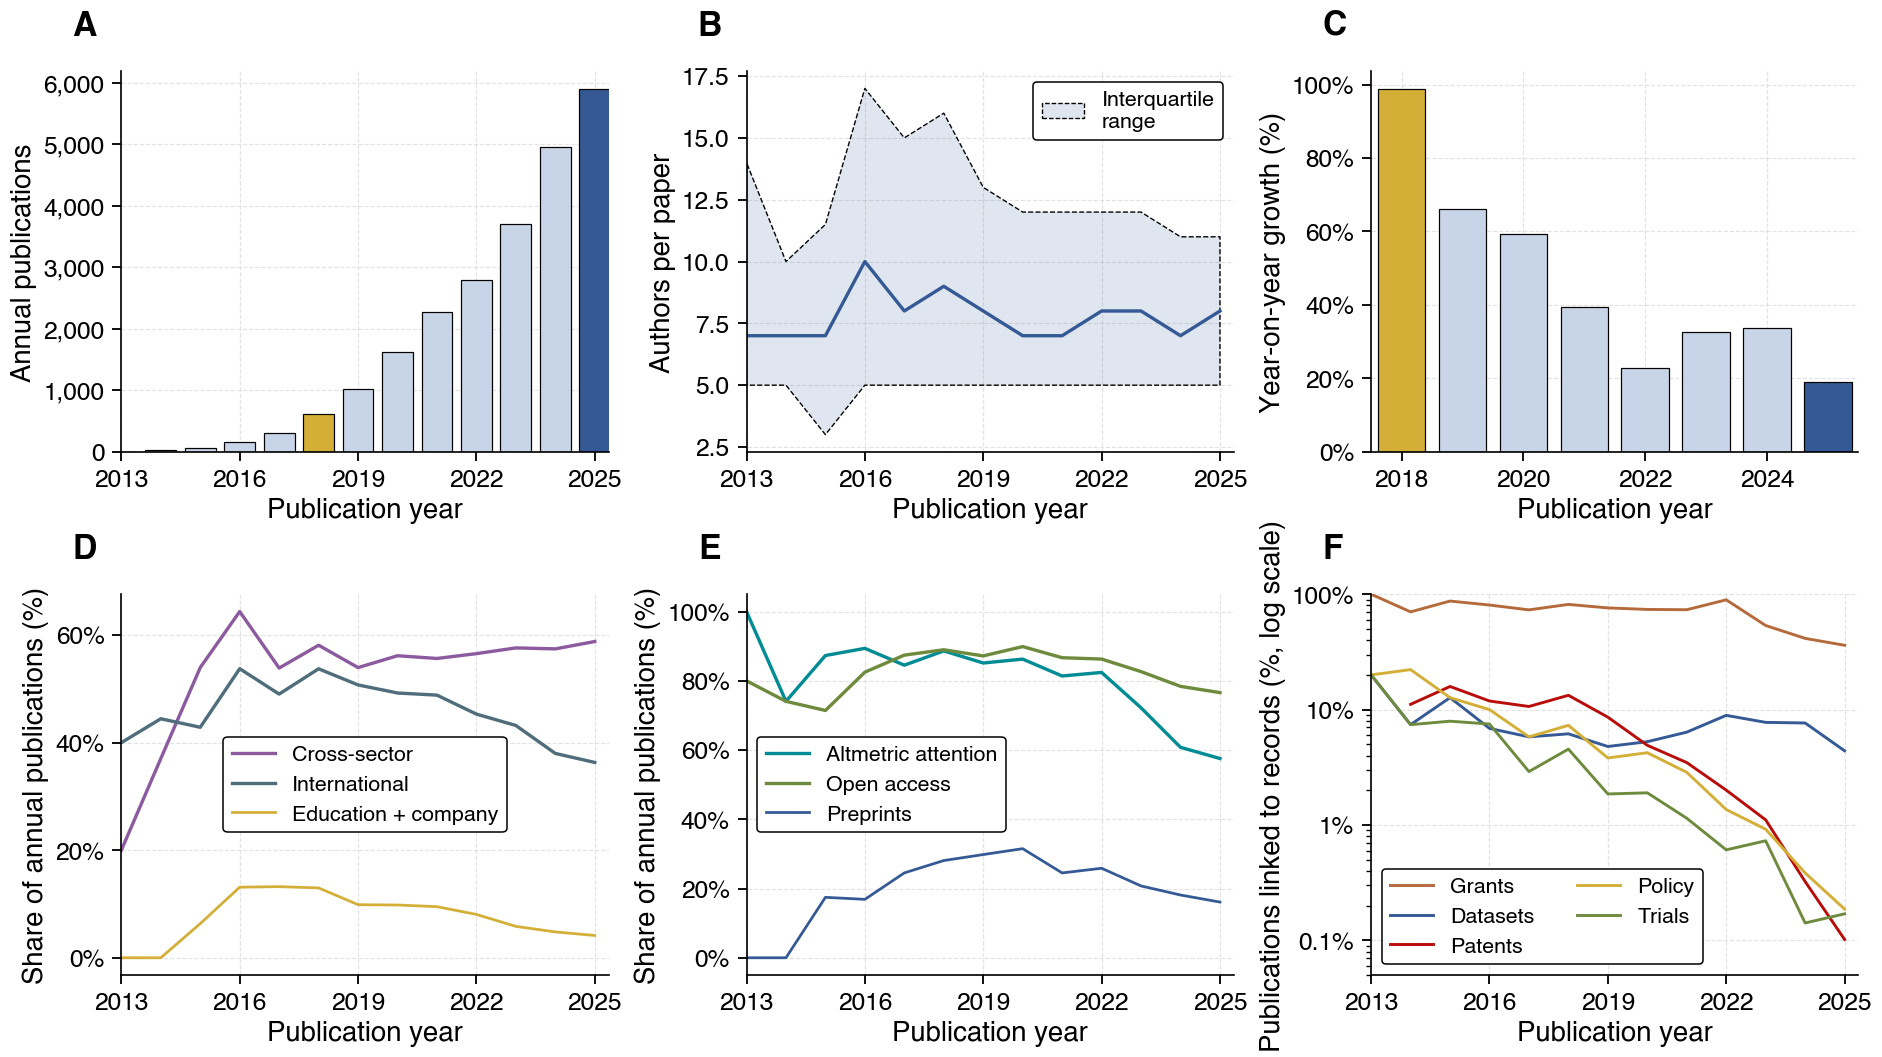

In [11]:
fig = G.plot_annual_growth_supplement(
    annual,
    sector_by_year,
    STYLE,
    METRIC_COLORS,
    PLOT,
    baseline,
    LAST_COMPLETE_YEAR,
)
record_figure(savefig(fig, "01_02_supplementary_figure_01_annual_growth"))
plt.show()
plt.close(fig)

## Supplementary figure 2: overlap between forms of reach

Panel A reports pairwise Jaccard similarity for seven publication-level indicators. Because Jaccard similarity is symmetric, only the nonredundant lower triangle is shown and self-comparisons are omitted. Panel B gives each indicator's prevalence in the complete-year corpus. International collaboration is included here as additional context beyond the six indicators used consistently in Figure 1.

saved output/tables/data_analysis/01_growth/indicator_jaccard_similarity.csv
saved output/tables/data_analysis/01_growth/indicator_pairwise_overlap_counts.csv
saved output/tables/data_analysis/01_growth/indicator_prevalence.csv


saved output/figures/data_analysis/01_growth/01_03_supplementary_figure_02_indicator_overlap.pdf
saved output/figures/data_analysis/01_growth/01_03_supplementary_figure_02_indicator_overlap.svg


saved output/figures/data_analysis/01_growth/01_03_supplementary_figure_02_indicator_overlap.png


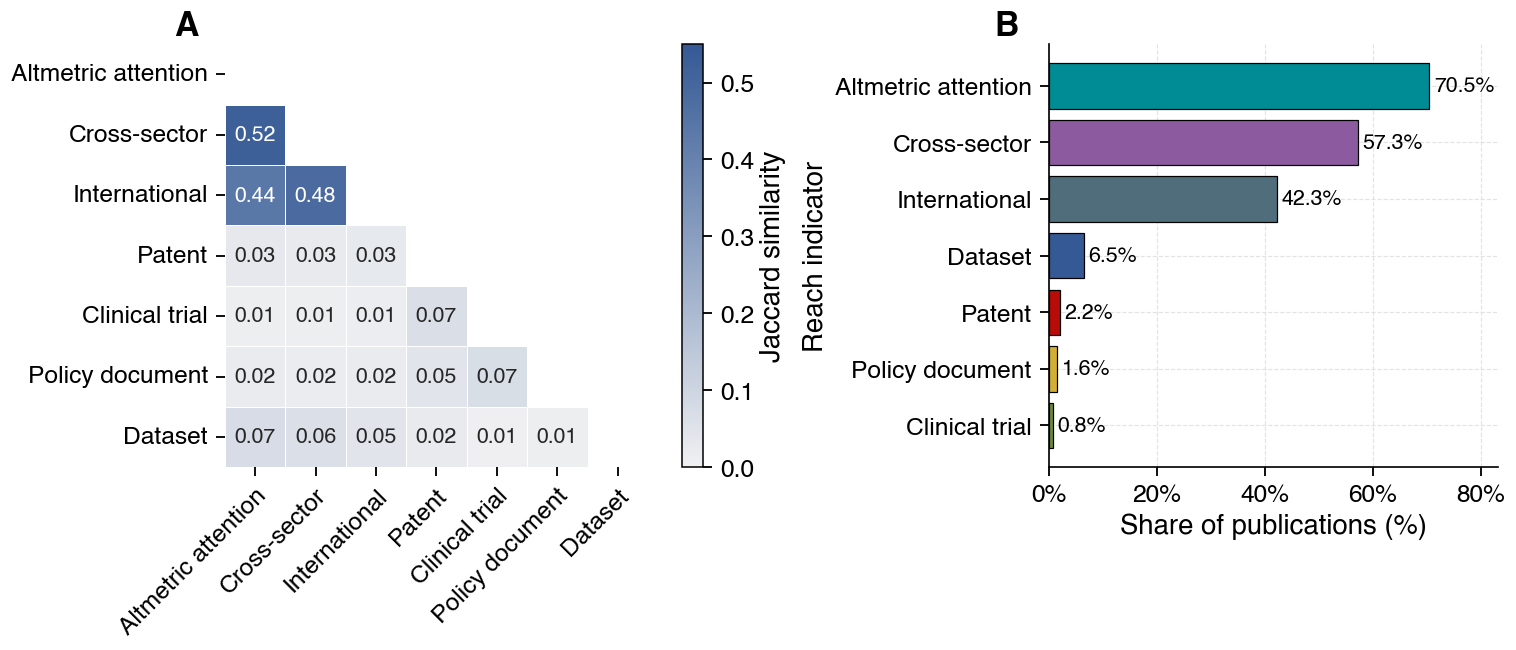

In [12]:
indicator_columns, indicator_colors = G.supplementary_indicator_specs(METRIC_COLORS)
jaccard, pair_counts, prevalence = G.indicator_overlap_tables(
    complete, indicator_columns
)
save_table(jaccard.reset_index(names="indicator"), "indicator_jaccard_similarity.csv")
save_table(pair_counts.reset_index(names="indicator"), "indicator_pairwise_overlap_counts.csv")
save_table(
    prevalence.rename_axis("indicator").reset_index(name="percent_of_papers"),
    "indicator_prevalence.csv",
)

fig = G.plot_indicator_overlap_supplement(
    jaccard,
    prevalence,
    indicator_colors,
    STYLE,
    METRIC_COLORS,
    PLOT,
)
record_figure(savefig(fig, "01_03_supplementary_figure_02_indicator_overlap"))
plt.show()
plt.close(fig)

## Export supplementary workbook, figure captions, methods text, and manifest

In [13]:
workbook_sheets = OrderedDict({
    "Headline statistics": headline,
    "Annual metrics": annual_out,
    "Growth periods": growth_period_summary,
    "Indicator milestones": indicator_accumulation_milestones,
    "Period composition": period_composition_summary,
    "Cross-sector composition": cross_sector_composition,
    "Endpoint summary": endpoint_summary,
    "Figure 1 indicator rates": indicator_rate_table.drop(columns="color"),
    "Figure 1 overlap": overlap_export,
    "Milestones": milestones,
    "Cross-sector by year": sector_by_year,
    "Event-year metrics": event_year_metrics,
    "Event-year audit": event_year_baseline_table,
    "Indicator prevalence": prevalence.rename_axis("indicator").reset_index(name="percent_of_papers"),
    "Indicator Jaccard": jaccard.reset_index(names="indicator"),
    "Data quality": quality_audit,
    "Validation checks": validation_checks,
    "Metric definitions": metric_definitions,
})
workbook_path = ARTIFACTS.save_workbook(
    workbook_sheets, "supplementary_growth_tables.xlsx"
)

main_caption = (
    f"Figure 1 | Growth and reach of UK Biobank research, {FIRST_YEAR}–{LAST_COMPLETE_YEAR}. "
    "(A) Cumulative unique publications; inset curves show cumulative publications linked "
    "to patents, clinical trials, policy documents or datasets, with cross-sector "
    "collaboration, or with a positive aggregate Altmetric score. Cross-sector collaboration "
    "requires at least one Education organization and at least one Company, Government, "
    "Healthcare or Nonprofit organization. (B) Annual publication output, with 2018 and 2025 "
    "highlighted; the annotation reports compound annual growth over that interval. (C) "
    "Publications carrying each of the same six indicators per 1,000 publications across "
    "2013–2025, shown on a logarithmic axis. (D) Directional co-occurrence among the same "
    "six indicators across the complete-year corpus. Each off-diagonal cell is the percentage "
    "of publications carrying the row indicator that also carry the column indicator; the "
    "diagonal is omitted. Row colors identify indicators consistently across A, C and D. "
    "Publications contribute once to each "
    "applicable indicator and indicators may overlap. Linked-endpoint indicators reflect links "
    "available at the data cutoff and may be lower for recent cohorts because links accrue over "
    "time. Citation and Altmetric values are snapshot measures. Records "
    "from incomplete year 2026 were excluded. News-specific mention counts were unavailable."
)
ARTIFACTS.save_text(main_caption + "\n", "figure_01_caption.txt")

supplementary_1_caption = (
    f"Supplementary Figure 1 | Annual growth, collaboration and reach of UK Biobank "
    f"publications, {FIRST_YEAR}–{LAST_COMPLETE_YEAR}. (A) Annual publication output. "
    "(B) Median authors per paper with the interquartile range. (C) Year-on-year growth "
    "from 2018, with 2018 and 2025 highlighted. (D) Annual shares of cross-sector and "
    "international collaborations and Education–Company collaborations. (E) Annual shares "
    "with Altmetric attention, open-access status and preprint publication type. (F) Annual "
    "shares linked to grants, datasets, patents, policy documents and clinical trials, shown "
    "on a logarithmic scale. Endpoint links, Altmetric scores and open-access status reflect "
    "the source snapshot; recent publication cohorts may be affected by indexing, linkage "
    "and attention-accrual latency."
)
ARTIFACTS.save_text(
    supplementary_1_caption + "\n", "supplementary_figure_01_caption.txt"
)

supplementary_2_caption = (
    f"Supplementary Figure 2 | Overlap between forms of reach among UK Biobank "
    f"publications, {FIRST_YEAR}–{LAST_COMPLETE_YEAR}. (A) Pairwise Jaccard similarity "
    "between seven binary publication indicators. The nonredundant lower triangle is shown; "
    "self-comparisons are omitted. (B) Percentage of complete-year publications carrying "
    "each indicator. Publications may carry multiple indicators. Endpoint links and positive "
    "aggregate Altmetric scores reflect the source snapshot."
)
ARTIFACTS.save_text(
    supplementary_2_caption + "\n", "supplementary_figure_02_caption.txt"
)

methods_text = (
    f"The growth analysis used the Dimensions all-endpoints-wide UK Biobank publication "
    f"parquet with a data cutoff of {DATA_CUTOFF.date().isoformat()}. Publication "
    f"trends were restricted to complete calendar years {FIRST_YEAR}–{LAST_COMPLETE_YEAR}; "
    f"provisional 2026 records were retained only for data-quality auditing. Publications were "
    f"deduplicated by Dimensions ID. Clinical trials, patents, policy documents, grants and "
    f"datasets were reconstructed from paired endpoint ID and event-date arrays and "
    f"deduplicated by endpoint ID; IDs without corresponding dates were retained with a "
    f"missing event year. In the primary figure, a publication carried an endpoint "
    f"indicator when at least one linked endpoint ID was present; it contributed once per "
    f"indicator, and indicators were allowed to overlap. Conditional co-occurrence in Figure 1D "
    f"was the pairwise intersection divided by the number of publications carrying the row "
    f"indicator; diagonal self-comparisons were omitted. Unique endpoint tables assigned "
    f"each endpoint to the publication year of its earliest linked UK "
    f"Biobank paper. Cross-sector collaboration "
    f"required both an Education organization and at least one Company, Government, Healthcare "
    f"or Nonprofit organization. Sector-specific cross-sector categories were not mutually "
    f"exclusive. International collaboration required at least two research-"
    f"organization countries. Open-access papers contained oa_all in the source access array, "
    f"and preprints had Dimensions publication type preprint. Altmetric and citation measures "
    f"represent the current values "
    f"stored in the parquet and were grouped by publication year; the data did not contain "
    f"news-specific mention counts. Supplementary pairwise overlap used the Jaccard "
    f"intersection-over-union coefficient; the symmetric upper triangle and diagonal were "
    f"omitted from the display. Linked-endpoint prevalence for recent publication cohorts "
    f"may be affected by indexing and linkage latency."
)
methods_path = ARTIFACTS.save_text(
    methods_text + "\n", "methods_growth_metrics.txt"
)

manifest, manifest_path = ARTIFACTS.save_manifest("growth_analysis_manifest.csv")

print(
    f"\nExported {len(ARTIFACTS.figure_paths)} figure files "
    f"({len(ARTIFACTS.figure_paths) // 3} figures × 3 formats) and "
    f"{len(ARTIFACTS.table_paths) + 1} table/text deliverables."
)
manifest_summary = (
    manifest.groupby(["kind", "format"]).size()
    .unstack(fill_value=0)
    .reset_index()
)
display(manifest_summary)
display(Markdown("**Analysis complete.** All displayed and exported paths are repository-relative."))

saved output/tables/data_analysis/01_growth/supplementary_growth_tables.xlsx
saved output/tables/data_analysis/01_growth/figure_01_caption.txt
saved output/tables/data_analysis/01_growth/supplementary_figure_01_caption.txt
saved output/tables/data_analysis/01_growth/supplementary_figure_02_caption.txt
saved output/tables/data_analysis/01_growth/methods_growth_metrics.txt
saved output/tables/data_analysis/01_growth/growth_analysis_manifest.csv

Exported 9 figure files (3 figures × 3 formats) and 26 table/text deliverables.


format,kind,csv,pdf,png,svg,txt,xlsx
0,figure,0,3,3,3,0,0
1,table_or_text,20,0,0,0,4,1


**Analysis complete.** All displayed and exported paths are repository-relative.